# Ecommerce Text Classification

## Суть задачи
Нужно классифицировать описание товара (product description) по одной из 4 категорий:

- Electronics  
- Household  
- Books  
- Clothing & Accessories

## Данные

**Формат:** CSV-файл с двумя колонками:
- Название класса (категория)
- Текст (название + описание товара)

**Количество примеров:** 50 425  
**Количество классов:** 4

Проведем разведочный анализ данных с целью определения их особенностей и возможных алгоритмов их предобработки для построения предсказательных моделей

In [1]:
%load_ext autoreload
%autoreload 2

## Импорт необходимых библиотек и модулей

In [2]:
import pandas as pd

In [3]:
from core.utils import *
from core.nlp import *
from core.visualization import *

Для воспроизводимости экспериментов

In [4]:
init_random_seed(316)

## Загрузка и изучение структуры данных

In [5]:
data_path = 'data'

In [6]:
data = pd.read_csv(f"{data_path}/ecommerceDataset.csv", header=None, names=["category", "description"])
data.sample(5)

,category,description
6692,Household,Handmade Butterfly Beaded Napkin Rings Set Of ...
37043,Clothing & Accessories,Urbaano G-Strings Eco Pack of Three A very hot...
48509,Electronics,By Pioneer BDP-180 Network 3D Blu-Ray Player w...
16111,Household,Mitashi 6.2 kg Fully-Automatic Top Loading Was...
23949,Books,Fear: Trump in the White House Review `As spec...


Посмотрим на столбцы в датасете

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50425 entries, 0 to 50424
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   category     50425 non-null  object
 1   description  50424 non-null  object
dtypes: object(2)
memory usage: 788.0+ KB


## Проверка на корректность и качество данных

### Проверка на дубликаты

Дублированные записи могут искажать результаты анализа и обучения модели, а также приводить к переобучению

In [8]:
print(data.duplicated().sum())

22622


In [9]:
data[data.duplicated(keep=False)].value_counts().tolist()

[30,
 29,
 26,
 23,
 22,
 20,
 19,
 19,
 19,
 19,
 19,
 18,
 18,
 17,
 17,
 17,
 16,
 16,
 16,
 15,
 15,
 15,
 15,
 14,
 14,
 14,
 14,
 14,
 14,
 14,
 14,
 14,
 14,
 13,
 13,
 13,
 13,
 13,
 13,
 13,
 13,
 13,
 13,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 11,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8

In [10]:
data[data.duplicated(keep=False)].sort_values("description").head(20)

,category,description
1932,Household,# The Silky Beans 2 KG Premium Bean Bag Filler...
1906,Household,# The Silky Beans 2 KG Premium Bean Bag Filler...
2433,Household,# The Silky Beans 2 KG Premium Bean Bag Filler...
2442,Household,# The Silky Beans 2 KG Premium Bean Bag Filler...
1931,Household,# The Silky Beans 500 Gram Premium A-Grade for...
1919,Household,# The Silky Beans 500 Gram Premium A-Grade for...
2434,Household,# The Silky Beans 500 Gram Premium A-Grade for...
2436,Household,# The Silky Beans 500 Gram Premium A-Grade for...
20982,Books,#Horror
21010,Books,#Horror


In [20]:
data.drop_duplicates(inplace=True)
data.shape

(27802, 2)

### Проверка на пропуски

Пропущенные значения могут нарушить работу алгоритмов машинного обучения. Нужно понять, есть ли пропуски и как они распределены по столбцам

In [15]:
data.isna().sum()

category       0
description    1
dtype: int64

Посмотрим на пропуски

In [16]:
data[data["description"].isna()]

,category,description
39330,Clothing & Accessories,NaN


Большинство пропущенных ответов расцениваются как галлюцинации, что имеет место в контексте решаемой задачи. Заменим пропущенные значения на пустые строки для совместимости с алгоритмами машинного обучения

In [19]:
data.dropna(inplace=True)
data.shape

(27802, 2)

In [23]:
data.isna().sum()

category       0
description    0
dtype: int64

## Детальное изучение признаков (и таргета)

Анализ каждого признака для понимания их информативности и распределения. Это поможет выбрать правильные методы предобработки и понять, какие признаки наиболее важны для классификации

Создадим копию датафрейма для внесения в нее изменений

In [24]:
data_eda = data.copy()

### Таргет (целевая переменная)

Посмотрим на распределение значений целевой переменной

In [26]:
data_eda["category"].value_counts()

category
Household                 10564
Books                      6256
Clothing & Accessories     5674
Electronics                5308
Name: count, dtype: int64

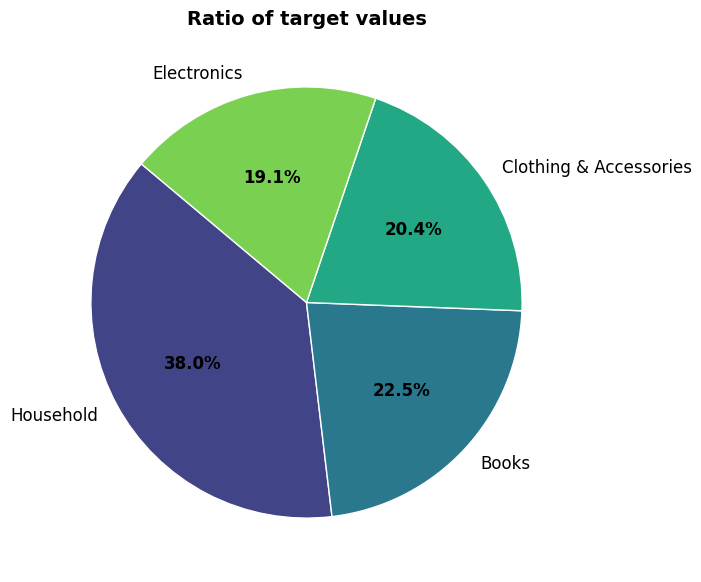

In [28]:
plot_pie_chart(data_eda, 'category', 'Ratio of target values')

Можно заметить небольшой дисбаланс в сторону класса "Household". Это говорит о том, что при анализе качества моделей мы можем полагаться только на устойчивые к дисбалансу метрики, а также использовать `pos_weight` в функции потерь для обучения нейронных сетей

### Анализ описаний товаров

Посчитаем длину описаний товаров в символах

In [29]:
data_eda['description_char_len'] = data_eda['description'].apply(len)
data_eda.sample(5)

,category,description,description_char_len
21219,Books,The Land of Stories: Worlds Collide About the ...,604
769,Household,Spacewood Ciara Dresser Table with Stool (Waln...,758
36248,Clothing & Accessories,V. K. Jewels Silver Twin Leaf Rhodium Plated R...,414
9399,Household,Embassy Stainless Steel Multipurpose Lid with ...,382
35221,Clothing & Accessories,AMERICAN CREW Men's Polyester Trackpants Slip ...,848


Рассмотрим ее описательные статистики

In [36]:
data_eda['description_char_len'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
description_char_len,27802.0,699.994928,1023.019517,4.0,215.0,473.0,916.75,50403.0


Визуализируем ее распределение

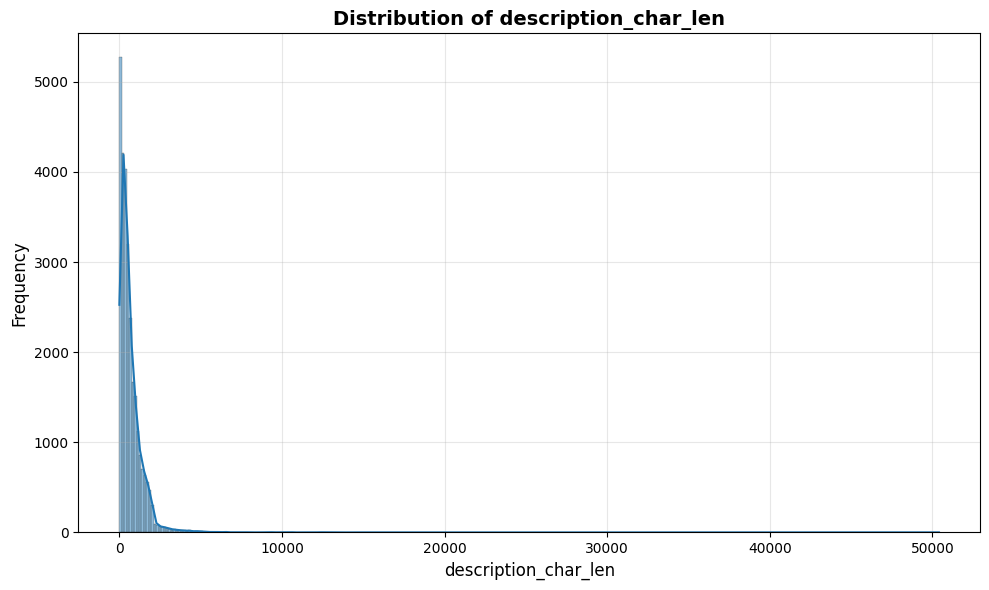

In [37]:
plot_histogram_numeric(data_eda, 'description_char_len', figsize=(10, 6))

Можно заметить, что имеются выбросы - давайте их изучим

(38, 3)


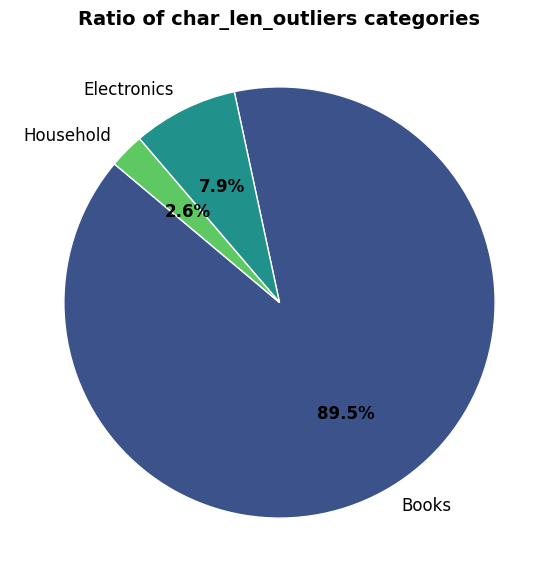

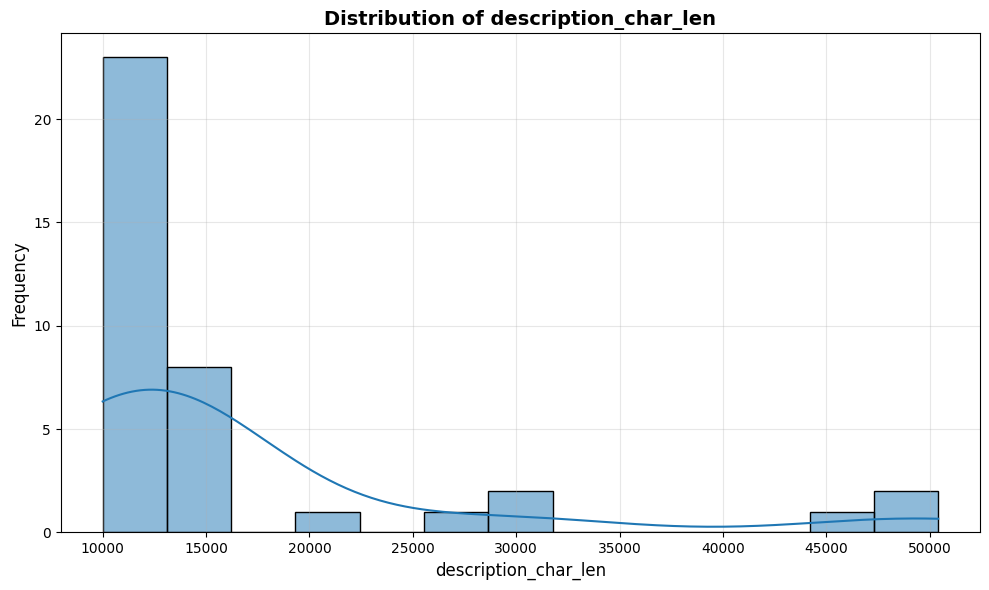

In [51]:
char_len_outliers = data_eda[data_eda["description_char_len"] > 10000]
print(char_len_outliers.shape)
plot_pie_chart(char_len_outliers, 'category', 'Ratio of char_len_outliers categories')
plot_histogram_numeric(char_len_outliers, 'description_char_len', figsize=(10, 6))

Большинство выбросов из категорий книги и общее количество равно 38

Токенизируем описания и рассмотрим их длины в токенах

In [52]:
data_eda['description_tokenized_tiktoken'] = data_eda['description'].apply(tokenize_tiktoken)
data_eda['description_tokenized_tiktoken_len'] = data_eda['description_tokenized_tiktoken'].apply(len)

data_eda.sample(5)

,category,description,description_char_len,description_tokenized_tiktoken,description_tokenized_tiktoken_len
730,Household,Nisha Furniture Sheesham Wood Bedside Table fo...,1761,"[n, isha, furniture, she, esh, am, wood, bed, ...",410
10010,Household,Darkpyros 6 pcs Primium Quality Multipurpose S...,754,"[dark, py, ros, 6, pcs, prim, ium, quality, mu...",167
40663,Electronics,APC BE800-IND 12AH Builtin UPS (Black) Product...,1823,"[ap, c, be, 800, -, ind, 12, ah, b, uiltin, up...",325
6092,Household,"ONLY MAT Coir Door Mats, 30"" x 18"", Beige - Pa...",137,"[only, mat, co, ir, door, mats, ,, 30, "", x, 1...",38
10875,Household,Servesafe Stainless Steel Colour Coded Oven Th...,847,"[s, erves, afe, stainless, steel, colour, c, o...",182


Посчитаем число появлений каждого токена и выведем 50 наиболее встречаемых

In [55]:
description_token_counts = token_counts(
    data_eda,
    'description_tokenized_tiktoken',
    remove_stopwords=True,
    remove_punctuation=True,
    lowercase_for_counting=True
)

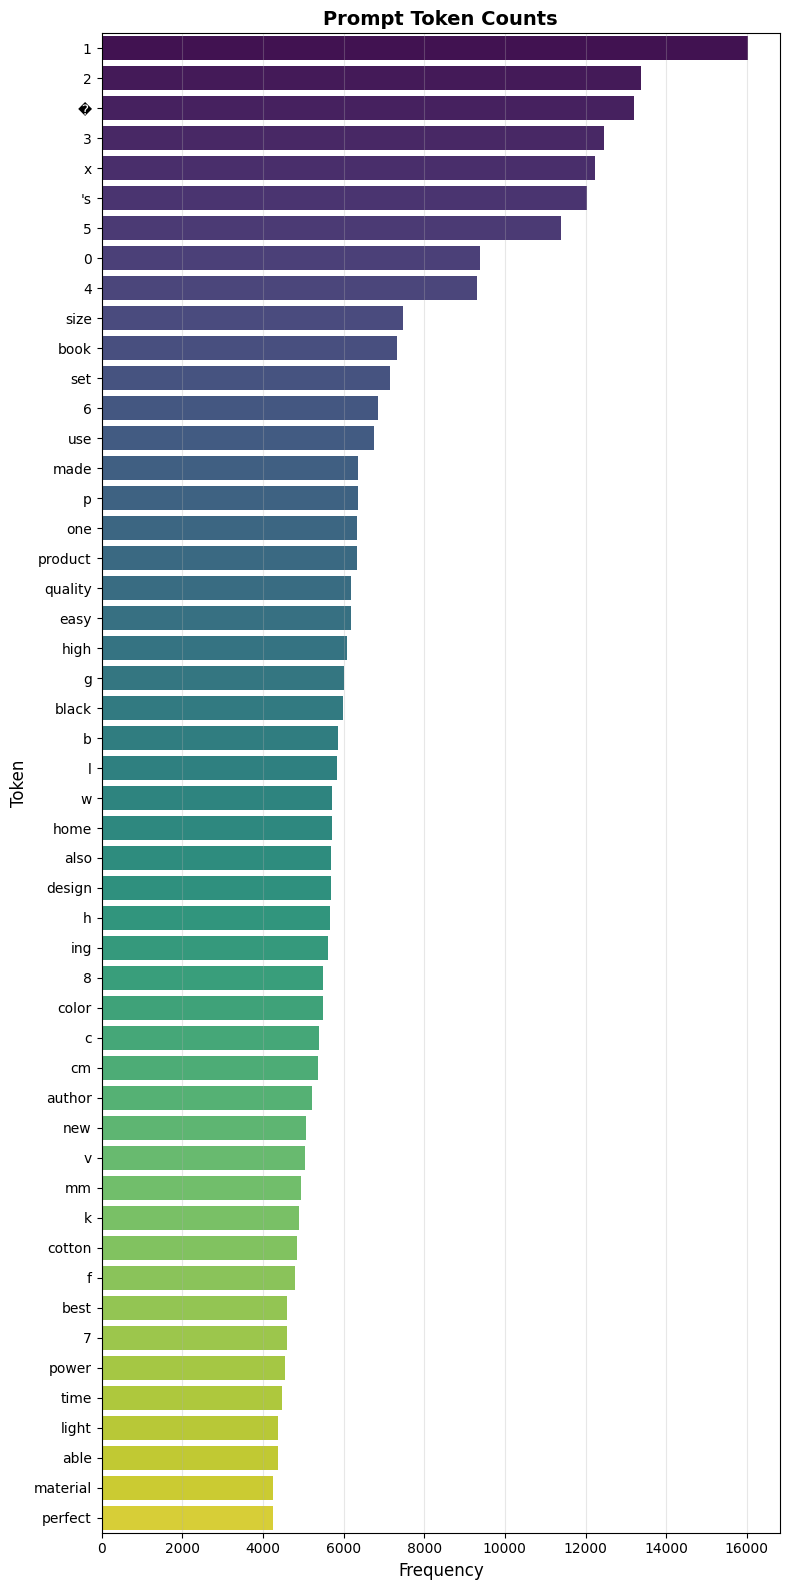

In [56]:
barplot(
    description_token_counts,
    title='Prompt Token Counts',
    y_label='Token',
    top_n=50,
    figsize=(8, 16)
)

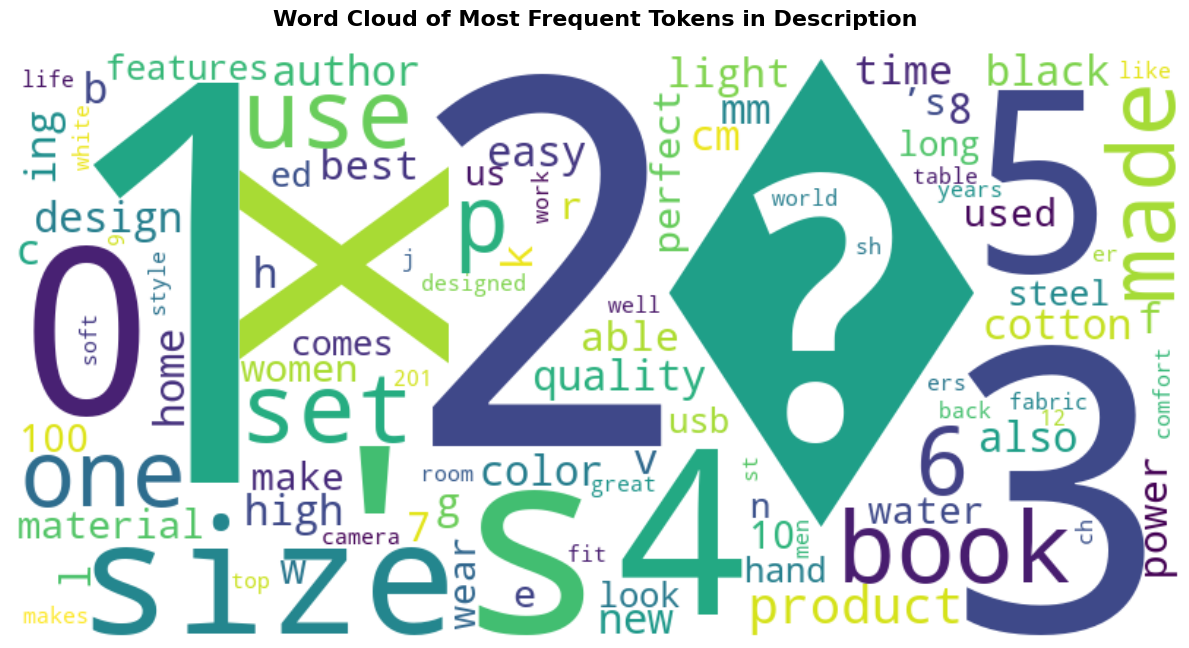

In [58]:
plot_wordcloud(
    description_token_counts,
    title='Word Cloud of Most Frequent Tokens in Description', 
    max_words=100
)

Также построим гистограмму распределения длин описаний в токенах

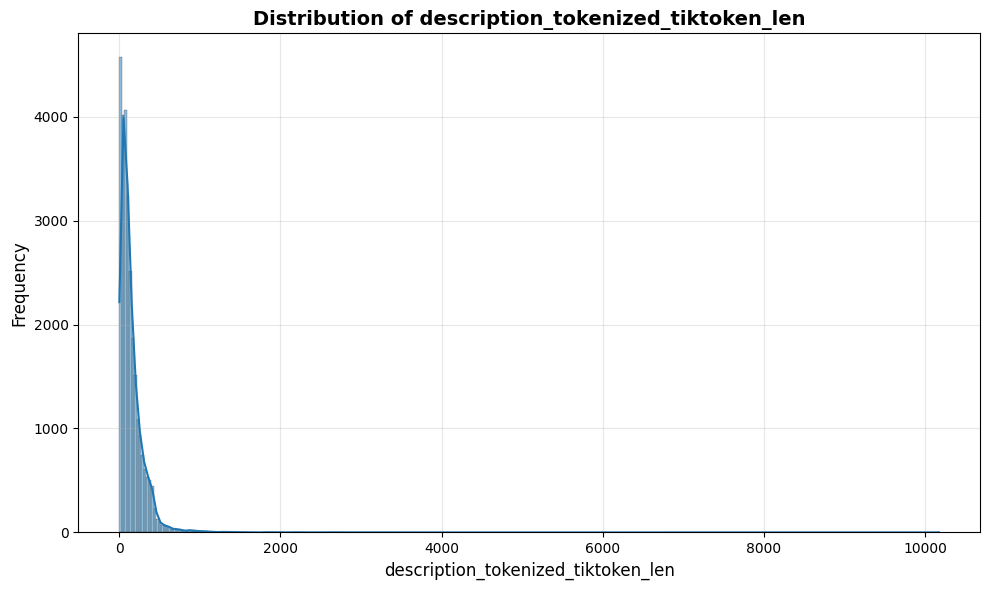

In [60]:
plot_histogram_numeric(data_eda, 'description_tokenized_tiktoken_len', figsize=(10, 6))

Очистим токены промпта от пунктуации и стоп-слов и посчитаем важность токенов для классификации

In [61]:
data_eda['description_tokenized_tiktoken_clean'] = data_eda['description_tokenized_tiktoken'].apply(lambda tokens: filter_tokens(
    tokens,
    remove_stopwords=True,
    remove_punctuation_tokens=True,
    lowercase_for_counting=True
))

data_eda.sample(5)

,category,description,description_char_len,description_tokenized_tiktoken,description_tokenized_tiktoken_len,description_tokenized_tiktoken_clean
642,Household,"Trust basket Single Pot Railing Planter, Set o...",942,"[trust, basket, single, pot, r, ailing, plan, ...",209,"[trust, basket, single, pot, r, ailing, plan, ..."
20919,Books,HBR Guide to Data Analytics Basics for Manager...,60,"[h, br, guide, to, data, analytics, basics, fo...",14,"[h, br, guide, data, analytics, basics, manage..."
17763,Household,"Kitsch SS Square 450mm(18"") Long Shower Arm Fo...",759,"[k, its, ch, ss, square, 450, mm, (, 18, ""), l...",168,"[k, ch, ss, square, 450, mm, 18, long, shower,..."
45079,Electronics,AmazonBasics 3.5 mm Coiled Stereo Audio Cable ...,1168,"[amazon, bas, ics, 3, ., 5, mm, co, iled, ster...",238,"[amazon, bas, ics, 3, 5, mm, co, iled, stereo,..."
15149,Household,Egab 12V DC Car Vacuum Cleaner (Silver) Suctio...,809,"[e, g, ab, 12, v, dc, car, vacuum, cleaner, (,...",180,"[e, g, ab, 12, v, dc, car, vacuum, cleaner, si..."


Посчитаем важность токенов для классификации. Будем использовать 1-граммы, 2-граммы и 3-граммы, а также анализировать токены, встретившиеся более 50 раз

In [62]:
prompt_token_counts = count_based_analysis(
    texts_tokenized=data_eda['description_tokenized_tiktoken_clean'],
    labels=data_eda['category'],
    n=3,
    metric='anova_f',
    min_count=50
)

prompt_token_counts.head(10)

,token,metric,count_Books,freq_Books,count_Clothing & Accessories,freq_Clothing & Accessories,count_Electronics,freq_Electronics,count_Household,freq_Household,total_count
0,author,2522.604148,5016,0.002519,15,0.000014,115,0.000061,70,0.000025,5216
1,women 's,1872.459479,62,0.000031,1727,0.001618,6,0.000003,32,0.000011,1827
2,cotton,1808.124446,20,0.000010,3633,0.003404,22,0.000012,1181,0.000417,4856
3,wear,1685.968333,36,0.000018,3321,0.003112,112,0.000060,220,0.000078,3689
4,men 's,1436.903592,45,0.000023,1350,0.001265,10,0.000005,63,0.000022,1468
5,review,1329.806663,2042,0.001025,8,0.000007,49,0.000026,63,0.000022,2162
6,book,1326.882737,6567,0.003297,12,0.000011,414,0.000221,341,0.000120,7334
7,books,1186.353797,2377,0.001194,3,0.000003,96,0.000051,125,0.000044,2601
8,'s cotton,1063.812834,2,0.000001,784,0.000735,0,0.000000,11,0.000004,797
9,women,1024.222812,445,0.000223,3475,0.003256,57,0.000030,191,0.000067,4168


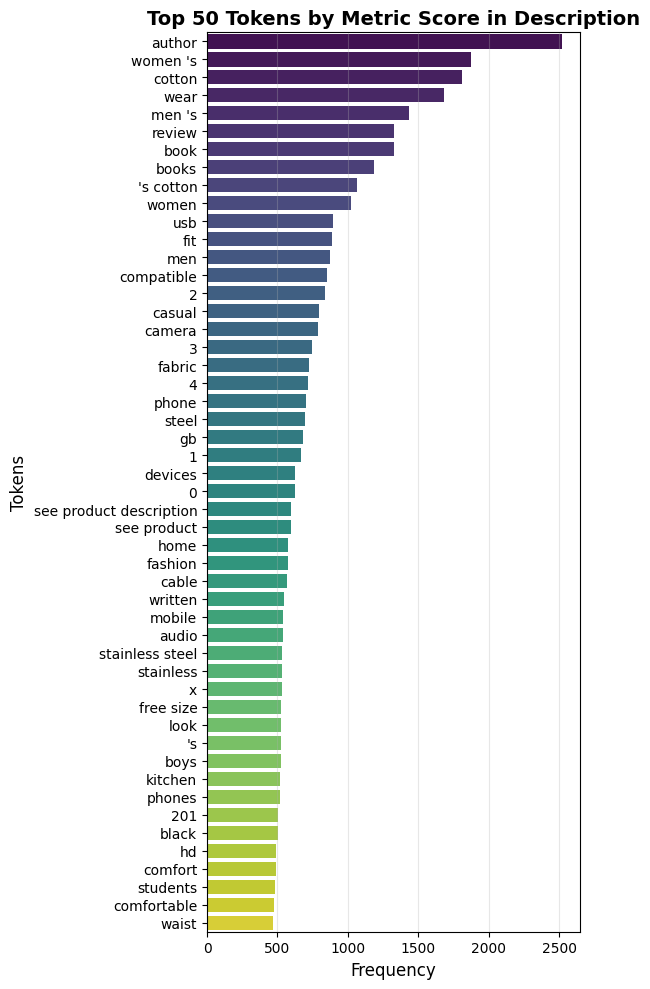

In [63]:
barplot_data_metric = prompt_token_counts.set_index('token')['metric'].head(50)
barplot(barplot_data_metric, 'Top 50 Tokens by Metric Score in Description', 'Tokens', figsize=(6, 10))

Посчитаем важность токенов без очистки стоп-слов и пунктуации

In [64]:
all_prompt_token_counts = count_based_analysis(
    texts_tokenized=data_eda['description_tokenized_tiktoken'],
    labels=data_eda['category'],
    n=3,
    metric='anova_f',
    min_count=50
)

all_prompt_token_counts.head(10)

,token,metric,count_Books,freq_Books,count_Clothing & Accessories,freq_Clothing & Accessories,count_Electronics,freq_Electronics,count_Household,freq_Household,total_count
0,about the author,4856.298729,2713,0.000783,7,0.000004,38,0.000013,41,0.000009,2799
1,the author,3889.683574,3498,0.001009,8,0.000005,61,0.000021,49,0.000011,3616
2,about the,3577.105280,3106,0.000896,64,0.000038,113,0.000039,162,0.000036,3445
3,author,2522.604148,5016,0.001447,15,0.000009,115,0.000040,70,0.000016,5216
4,women 's,1872.487557,62,0.000018,1726,0.001025,6,0.000002,32,0.000007,1826
5,cotton,1808.124446,20,0.000006,3633,0.002158,22,0.000008,1181,0.000262,4856
6,wear,1685.968333,36,0.000010,3321,0.001972,112,0.000039,220,0.000049,3689
7,about,1561.149990,4344,0.001253,305,0.000181,496,0.000171,739,0.000164,5884
8,men 's,1437.029270,45,0.000013,1349,0.000801,10,0.000003,63,0.000014,1467
9,review,1329.806663,2042,0.000589,8,0.000005,49,0.000017,63,0.000014,2162


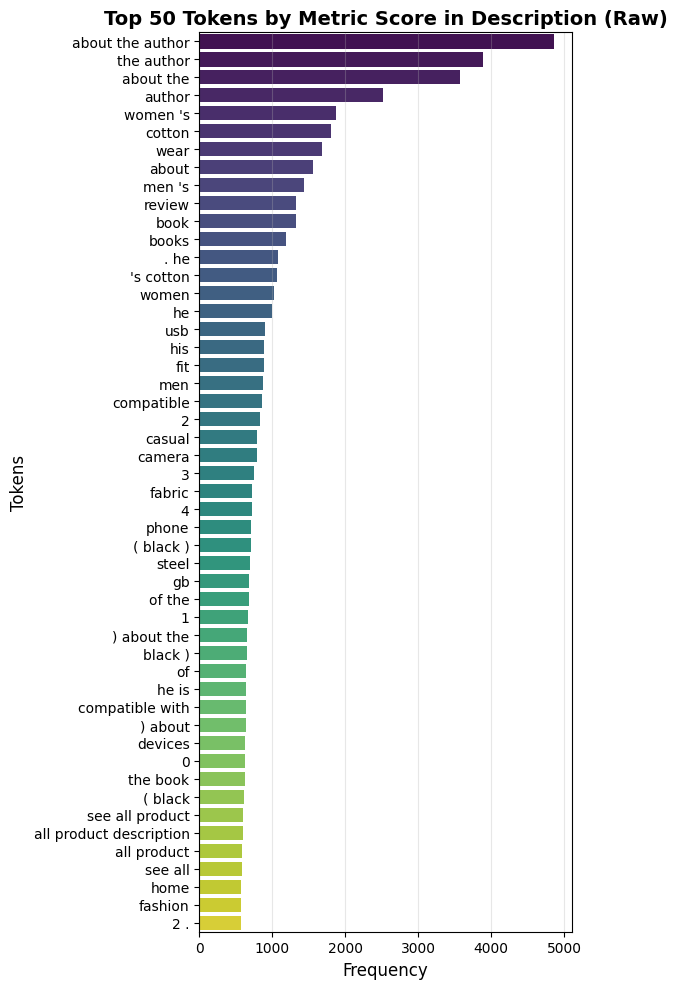

In [65]:
barplot_data_metric = all_prompt_token_counts.set_index('token')['metric'].head(50)
barplot(barplot_data_metric, 'Top 50 Tokens by Metric Score in Description (Raw)', 'Tokens', figsize=(6, 10))

Видно, что последовательность важности токенов осталось примерно такой же. 

## Выводы

В ходе предварительного анализа данных были выявлены следующие особенности:

1) Наблюдается небольшой дисбаланс классов => необходимо использовать устойчивые к дисбалансу метрики качества и `pos_weight` при обучении нейронных сетей;
2) Распределения длин description имеют длинный правый хвост => необходим порог максимальной обрабатываемой длины последовательности;
3) Почти половина датасета состоит из дубликатов
4) При удалении стоп-слов и токенов пунктуации для description несильно меняется топ комбинаций токенов по важности для классификации => необходимо проверить модели работающие по всем и только по "информативным" токенам